In [1]:
import pyodbc
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Définir les informations de connexion
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Établir la connexion
try:
    connection = pyodbc.connect('DRIVER={SQL Server};SERVER='+server+';DATABASE='+database+';UID='+username+';PWD='+password)
    print("Connexion réussie à la base de données SQL Server")
    
    # Définir la requête SQL
    query = """
    SELECT f.ordered_quantity, r.start_time, r.product_group_code
    FROM fact_sales AS f
    INNER JOIN dim_order_recipe AS r ON f.FK_ORDER_RECIPE = r.pk_order_recipe
    WHERE r.product_group_code = 'PT' 
    """
    
    # Exécuter la requête SQL et récupérer les résultats dans un DataFrame pandas
    result = pd.read_sql(query, connection)
    
    # Convertir la colonne de dates en datetime
    result['start_time_date'] = pd.to_datetime(result['start_time'])
    
    # Définir la colonne 'start_time_date' comme index
    result.set_index('start_time_date', inplace=True)
    
    # Regrouper par mois et calculer la somme des quantités commandées pour chaque mois
    result = result.resample('M').sum(numeric_only=True).reset_index()
    
    # Afficher les résultats
    print("Résultats de la série temporelle regroupés par mois :")
    print(result)

except pyodbc.Error as e:
    print("Erreur lors de la connexion à la base de données SQL Server :", e)

# Convertir la colonne de dates en format de mois
result['month'] = result['start_time_date'].dt.to_period('M')

# Agréger les données par mois et calculer la somme de la quantité
monthly_sum = result.groupby('month')['ordered_quantity'].sum().reset_index()

# Stocker les sommes mensuelles dans un fichier CSV
monthly_sum.to_csv("monthly_sum_PT.csv", index=False)

import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('monthly_sum_PT.csv')

# Convert the 'month' column to datetime
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Add 1 month before the first month in the DataFrame
start_date = df['month'].min()
extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')
extra_data = pd.DataFrame({'month': extra_months, 'ordered_quantity': np.nan})
df = pd.concat([extra_data, df])

# Replace outliers
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 0.5 * IQR
    upper_bound = Q3 + 0.5 * IQR
    df[column] = df[column].apply(lambda x: x if (x >= lower_bound and x <= upper_bound) else np.nan)
    return df

df = replace_outliers(df, 'ordered_quantity')

# Compute median for each month
monthly_medians = df.groupby(df['month'].dt.month)['ordered_quantity'].median()

# Function to impute missing values based on month
def impute_missing_values_by_month(df, column):
    df[column] = df.apply(lambda row: monthly_medians[row['month'].month] if pd.isna(row[column]) else row[column], axis=1)
    return df

# Impute missing values
df = impute_missing_values_by_month(df, 'ordered_quantity')

# Save the modified DataFrame
df.to_csv('monthly_sum_PT_modified.csv', index=False)

print(df)

# Read and display the modified file
df_modified = pd.read_csv('monthly_sum_PT_modified.csv', parse_dates=['month'], index_col=['month'])
print(df_modified.head())


Connexion réussie à la base de données SQL Server


C:\Users\user\AppData\Local\Temp\ipykernel_28620\4131874757.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, connection)


Résultats de la série temporelle regroupés par mois :
   start_time_date  ordered_quantity
0       2021-10-31             99000
1       2021-11-30            257000
2       2021-12-31            191000
3       2022-01-31            760000
4       2022-02-28                 0
5       2022-03-31            290000
6       2022-04-30            122000
7       2022-05-31            305600
8       2022-06-30            426000
9       2022-07-31            398000
10      2022-08-31            290000
11      2022-09-30            310600
12      2022-10-31            260000
13      2022-11-30            313000
14      2022-12-31            916000
15      2023-01-31           1060000
16      2023-02-28            866200
17      2023-03-31            607000
18      2023-04-30            245000
19      2023-05-31            391000
20      2023-06-30            197100
21      2023-07-31            501000
22      2023-08-31            382000
23      2023-09-30            349937
24      2023-10-31   

C:\Users\user\AppData\Local\Temp\ipykernel_28620\4131874757.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  result = result.resample('M').sum(numeric_only=True).reset_index()
C:\Users\user\AppData\Local\Temp\ipykernel_28620\4131874757.py:69: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')


In [18]:

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


print("gaaaas")


df = pd.read_csv('monthly_sum_PT_modified.csv', parse_dates = ['month'], index_col = ['month'])
 
df.head()



    

gaaaas


,ordered_quantity
month,
2021-06-30,311550.0
2021-07-31,449500.0
2021-08-31,336000.0
2021-09-30,330268.5
2021-10-01,99000.0


Statistiques ADF : -1.3872403607737025
p-value : 0.5883777332029227
Valeurs Critiques :
	1%: -3.7238633119999998
	5%: -2.98648896
	10%: -2.6328004


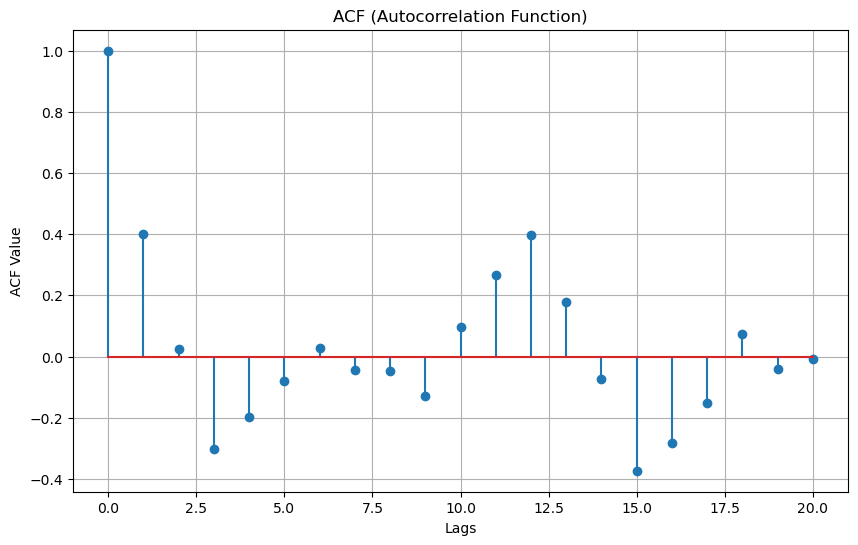

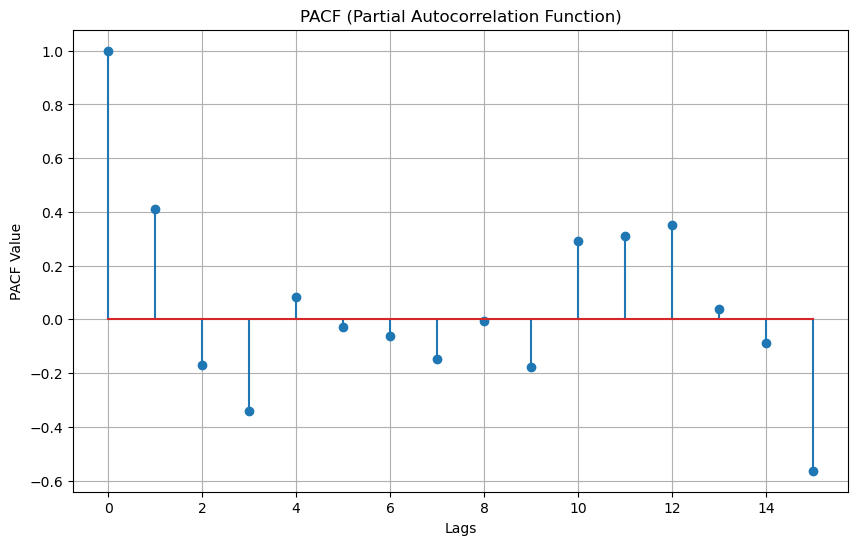

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Vérification de la stationnarité avec le test ADF
result = adfuller(df['ordered_quantity'])

print('Statistiques ADF : {}'.format(result[0]))
print('p-value : {}'.format(result[1]))
print('Valeurs Critiques :')
for key, value in result[4].items():
    print('\t{}: {}'.format(key, value))

# Affichage de l'ACF (Autocorrelation Function)
acf_values = acf(df['ordered_quantity'], nlags=20)  # Ajustez nlags selon la taille de vos données

# Tracer l'ACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(acf_values)), acf_values, use_line_collection=True)
plt.title('ACF (Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('ACF Value')
plt.grid()
plt.show()

# Affichage de la PACF (Partial Autocorrelation Function)
# Ajustez nlags pour qu'il soit inférieur à 50 % de la taille de votre échantillon
pacf_values = pacf(df['ordered_quantity'], nlags=15)

# Tracer la PACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(pacf_values)), pacf_values, use_line_collection=True)
plt.title('PACF (Partial Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('PACF Value')
plt.grid()
plt.show()


In [20]:
    
#############################log application ##########################

df_log = np.log(df)
df_log.head()

,ordered_quantity
month,
2021-06-30,12.649315
2021-07-31,13.015891
2021-08-31,12.724866
2021-09-30,12.707661
2021-10-01,11.502875


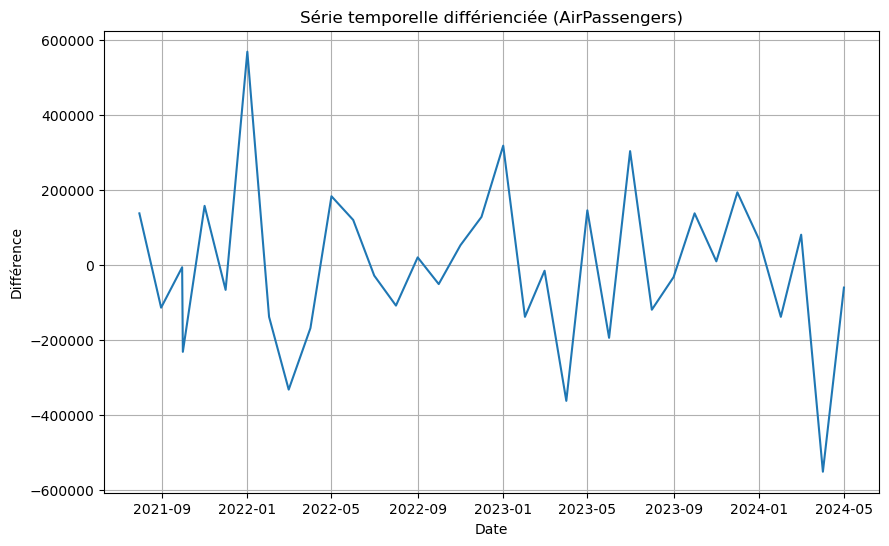

In [21]:
# Différenciation pour rendre la série stationnaire
differenced = df['ordered_quantity'].diff().dropna()

# Afficher la série différienciée
plt.figure(figsize=(10, 6))
plt.plot(differenced)
plt.title('Série temporelle différienciée (AirPassengers)')
plt.xlabel('Date')
plt.ylabel('Différence')
plt.grid(True)
plt.show()

In [22]:
# Analyse de la stationnarité de la variable
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

# Effectuer le test de Dickey-Fuller augmenté
result = adfuller(differenced)

# Formater les résultats dans un tableau
table = [
    ['Valeur de test', result[0]],
    ['P-valeur', result[1]],
    ['Conclusion', 'La série est stationnaire' if result[1] < 0.05 else 'La série est non stationnaire']
]

# Afficher les résultats sous forme de tableau
print(tabulate(table, headers=['Métrique', 'Valeur'], tablefmt='github'))

| Métrique       | Valeur                    |
|----------------|---------------------------|
| Valeur de test | -4.44706098977687         |
| P-valeur       | 0.00024479965198714003    |
| Conclusion     | La série est stationnaire |


In [23]:
from statsmodels.tsa.arima.model import ARIMA

# Créer un modèle ARIMA(2,1,1)
model = ARIMA(train_data, order=(1,0,1))

# Ajuster le modèle
model_fit = model.fit()

# Afficher le résumé du modèle
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       ordered_quantity   No. Observations:                   28
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -22.127
Date:                Sun, 11 Aug 2024   AIC                             52.254
Time:                        17:58:59   BIC                             57.583
Sample:                    07-01-2021   HQIC                            53.883
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0159      0.110      0.144      0.885      -0.200       0.232
ar.L1         -1.0000      0.033    -30.661      0.000      -1.064      -0.936
ma.L1          0.9970      4.106      0.243      0.8

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Training MAE: 0.43, MSE: 0.29, R2: 0.21
Test MAE: 0.50, MSE: 0.40, R2: -0.17


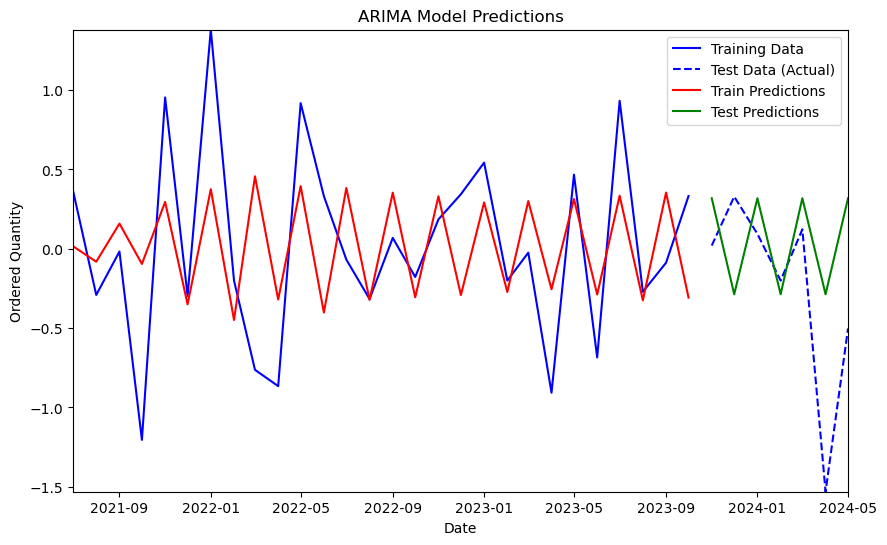

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Assurez-vous que les indices sont au format datetime
train_data.index = pd.to_datetime(train_data.index)
test_data.index = pd.to_datetime(test_data.index)

# Utiliser get_forecast pour les prédictions sur l'ensemble de test
train_predictions = model_fit.get_prediction(start=train_data.index[0], end=train_data.index[-1])
test_forecast = model_fit.get_forecast(steps=len(test_data))

# Extraire les valeurs prédites
train_pred_mean = train_predictions.predicted_mean
test_pred_mean = test_forecast.predicted_mean

# Calculer les métriques pour les données d'entraînement
mae_train = mean_absolute_error(train_data, train_pred_mean)
mse_train = mean_squared_error(train_data, train_pred_mean)
r2_train = r2_score(train_data, train_pred_mean)

# Calculer les métriques pour les données de test
mae_test = mean_absolute_error(test_data, test_pred_mean)
mse_test = mean_squared_error(test_data, test_pred_mean)
r2_test = r2_score(test_data, test_pred_mean)

print(f'Training MAE: {mae_train:.2f}, MSE: {mse_train:.2f}, R2: {r2_train:.2f}')
print(f'Test MAE: {mae_test:.2f}, MSE: {mse_test:.2f}, R2: {r2_test:.2f}')

# Visualiser les résultats
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue')
plt.plot(test_data.index, test_data.values, label='Test Data (Actual)', color='blue', linestyle='--')
plt.plot(train_data.index, train_pred_mean, label='Train Predictions', color='red')
plt.plot(test_data.index, test_pred_mean, label='Test Predictions', color='green')

# Définir les limites des axes pour une meilleure visualisation
plt.xlim(train_data.index[0], test_data.index[-1])
plt.ylim(min(train_data.min(), test_data.min()), max(train_data.max(), test_data.max()))

plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.title('ARIMA Model Predictions')
plt.legend()
plt.show()


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


MAE: 0.5004869526686722
MSE: 0.46105907775686794
RMSE: 0.6790133119143306
R²: 0.1626892815229194
            lower ordered_quantity  upper ordered_quantity   Forecast type
2024-06-01               11.782121               13.354305  12.568213   DS
2024-07-01               12.077318               13.716236  12.896777   DS
2024-08-01               12.291164               13.909790  13.100477   DS
2024-09-01               12.974236               14.616448  13.795342   DS
2024-10-01               12.735353               14.428855  13.582104   DS
2024-11-01               12.587317               14.198261  13.392789   DS
2024-12-01               11.860866               13.477615  12.669241   DS
2025-01-01               12.200659               13.862411  13.031535   DS
2025-02-01               11.905768               13.073770  12.489769   DS
2025-03-01               13.041564               14.208151  13.624857   DS
2025-04-01               12.784900               13.955050  13.369975   DS
202

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


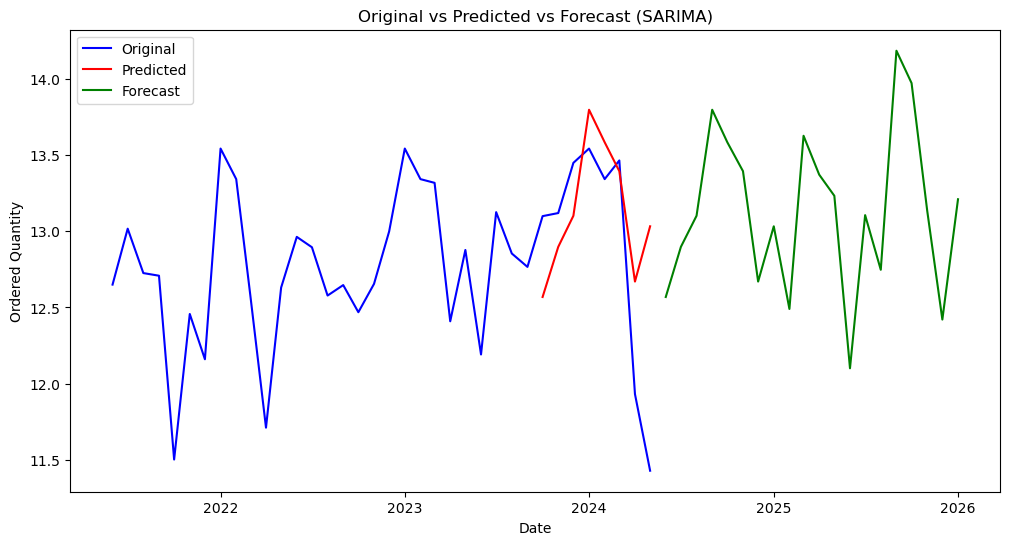

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle SARIMA sur l'ensemble d'apprentissage
# (p,d,q) x (P,D,Q,s) où s est la périodicité saisonnière, par exemple 12 pour les données mensuelles
model = SARIMAX(train_data, order=(2, 1, 3), seasonal_order=(2,1,3, 12))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions)
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.get_forecast(steps=20)
forecast_df = forecast.conf_int()
forecast_df['Forecast'] = forecast.predicted_mean

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_df.index = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'DS'

# Afficher le DataFrame avec les prédictions
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, df_log['ordered_quantity'], label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [40]:
import numpy as np
import pandas as pd
import pyodbc

# Assuming results and df_log are already defined in your session

# Prédire les 20 mois à venir
forecast = results.forecast(steps=20)

# Flatten the forecast if it's not 1D
if forecast.ndim > 1:
    forecast = forecast.flatten()

# Convertir les prédictions en antilogarithme
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "UL"
forecast_df['type'] = 'PT'

# Afficher le DataFrame
print(forecast_df)

# SQL Server connection details (ensure they are correct)
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Establish connection
conn = pyodbc.connect(f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password}')
cursor = conn.cursor()

# Backup the existing table if it exists
cursor.execute("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_NAME = 'dim_pred_orders_PT'")
table_exists = cursor.fetchone()[0]

if table_exists:
    # Backup existing table
    cursor.execute("SELECT * INTO dim_pred_orders_PT_backup FROM dim_pred_orders_PT")
    cursor.execute("DROP TABLE dim_pred_orders_PT")
    print("Existing table backed up and dropped successfully.")

# Create new table for forecast data
create_table_query = '''
CREATE TABLE dim_pred_orders_PT (
    Date DATE,
    Forecast FLOAT,
    type NVARCHAR(50),
    PRIMARY KEY (Date, Forecast, type)
)
'''
cursor.execute(create_table_query)
print("New table created successfully.")

# Insert forecast data
data_to_insert = [tuple(row) for row in forecast_df.values]
insert_query = '''
INSERT INTO dim_pred_orders_PT (Date, Forecast, type)
VALUES (?, ?, ?)
'''
cursor.executemany(insert_query, data_to_insert)

# Commit the transaction and close the connection
conn.commit()
conn.close()

print("Forecast data successfully inserted into dim_pred_orders_PT.")


                 Date      Forecast type
2023-10-01 2024-06-01  2.872801e+05   PT
2023-11-01 2024-07-01  3.990241e+05   PT
2023-12-01 2024-08-01  4.891756e+05   PT
2024-01-01 2024-09-01  9.800333e+05   PT
2024-02-01 2024-10-01  7.918314e+05   PT
2024-03-01 2024-11-01  6.552613e+05   PT
2024-04-01 2024-12-01  3.178201e+05   PT
2024-05-01 2025-01-01  4.565871e+05   PT
2024-06-01 2025-02-01  2.656060e+05   PT
2024-07-01 2025-03-01  8.264192e+05   PT
2024-08-01 2025-04-01  6.404813e+05   PT
2024-09-01 2025-05-01  5.575942e+05   PT
2024-10-01 2025-06-01  1.800446e+05   PT
2024-11-01 2025-07-01  4.912868e+05   PT
2024-12-01 2025-08-01  3.433195e+05   PT
2025-01-01 2025-09-01  1.443040e+06   PT
2025-02-01 2025-10-01  1.167046e+06   PT
2025-03-01 2025-11-01  5.054722e+05   PT
2025-04-01 2025-12-01  2.477918e+05   PT
2025-05-01 2026-01-01  5.451424e+05   PT
New table created successfully.
Forecast data successfully inserted into dim_pred_orders_PT.
